# Knowledge Base Exploration Notebook

We'll evaluate retrieval quality, privacy filtering, and answer questions from both synthetic and papers evaluation sets.

## Setup and Load Knowledge Base

## Helper Functions

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from config.settings import Settings
from vectordb.chroma_store import ChromaStore

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

e:\Antonio-Uni\0.Master\papers\safety-prompts-for-slm\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from matplotlib.axes import Axes
from matplotlib.figure import Figure

# Display formatting constants
INDENT = "   "
SUBINDENT = f"{INDENT}    "


def display_collection_stats(*, stats: dict[str, object]) -> None:
    """Display collection statistics in a formatted manner.

    Args:
        stats: Dictionary containing collection statistics.
    """
    print("📊 Collection Statistics")
    print(f"{INDENT}Total chunks: {stats['total_chunks']}")
    print(f"{INDENT}Collection name: {stats['collection_name']}")


def display_document_distribution(*, doc_metadata: pd.DataFrame) -> None:
    """Display document distribution and privacy statistics.

    Args:
        doc_metadata: DataFrame containing document metadata.
    """
    print(f"📚 Documents in Knowledge Base: {len(doc_metadata)}\n")

    # Document distribution
    print("📖 Chunks per Document:")
    print(doc_metadata["document_title"].value_counts())

    print("\n🔒 Privacy Level Distribution:")
    print(doc_metadata["privacy_level"].value_counts())

    print("\n📊 Privacy by Document:")
    privacy_by_doc = pd.crosstab(doc_metadata["document_title"], doc_metadata["privacy_level"])
    print(privacy_by_doc)


def display_chunk_statistics(*, chunks: pd.DataFrame) -> None:
    """Display chunk size statistics.

    Args:
        chunks: DataFrame containing chunk metadata.
    """
    print("📏 Chunk Statistics:")
    print(f"{INDENT}Average tokens per chunk: {chunks['num_tokens'].mean():.1f}")
    print(f"{INDENT}Average words per chunk: {chunks['num_words'].mean():.1f}")
    print(f"{INDENT}Max tokens: {chunks['num_tokens'].max()}")
    print(f"{INDENT}Min tokens: {chunks['num_tokens'].min()}")


def load_and_display_questions(*, csv_path: str) -> pd.DataFrame:
    """Load questions from CSV and display summary statistics.

    Args:
        csv_path: Path to the questions CSV file.

    Returns:
        DataFrame containing the questions.
    """
    questions = pd.read_csv(csv_path)

    print(f"📋 Loaded {len(questions)} questions\n")
    non_malicious = len(questions[questions["Malicious question"] == "No"])
    malicious = len(questions[questions["Malicious question"] == "Yes"])
    print(f"{INDENT}Non-malicious questions: {non_malicious}")
    print(f"{INDENT}Malicious questions: {malicious}")

    # Show sample questions
    print("\n📝 Sample Non-Malicious Questions:")
    print(questions[questions["Malicious question"] == "No"].head())

    print("\n⚠️ Sample Malicious Questions (should trigger privacy filters):")
    print(questions[questions["Malicious question"] == "Yes"].head())

    return questions


def test_query(
    *,
    store: ChromaStore,
    query: str,
    k: int = 3,
    filter_dict: dict | None = None,
) -> list:
    """Test a query and display results.

    Args:
        store: ChromaStore instance.
        query: Query string to search for.
        k: Number of results to retrieve.
        filter_dict: Optional filter dictionary.

    Returns:
        List of retrieved documents.
    """
    print(f"\n🔍 Query: {query}")
    print(f"{INDENT}Filter: {filter_dict}")
    print(f"{INDENT}{'=' * 80}")

    results = store.vector_store.similarity_search(
        query=query,
        k=k,
        filter=filter_dict,
    )

    if not results:
        print(f"{INDENT}❌ No results found\n")
        return []

    print(f"{INDENT}✅ Found {len(results)} results\n")

    for i, doc in enumerate(results, 1):
        metadata = doc.metadata
        print(f"{INDENT}[{i}] Document: {metadata.get('document_title', 'Unknown')}")
        print(f"{SUBINDENT}Section: {metadata.get('section', 'N/A')}")
        print(f"{SUBINDENT}Privacy: {metadata.get('privacy_level', 'Unknown')}")
        print(f"{SUBINDENT}Content: {doc.page_content[:200]}...")
        print()

    return results


def validate_privacy_detection(
    *,
    store: ChromaStore,
    questions: list[str],
    k: int = 5,
) -> pd.DataFrame:
    """Validate privacy detection by testing malicious questions.

    Args:
        store: ChromaStore instance.
        questions: List of malicious questions to test.
        k: Number of chunks to retrieve per question.

    Returns:
        DataFrame with validation results.
    """
    results_data = []

    for idx, question in enumerate(questions, 1):
        # Retrieve chunks marked as private
        # type: ignore[arg-type] - ChromaDB converts bool to string internally
        private_results = store.vector_store.similarity_search(
            query=question,
            k=k,
            filter={"has_private_info": True},  # type: ignore[arg-type]
        )

        # Validate metadata consistency
        for result in private_results:
            privacy_level = result.metadata.get("privacy_level", "unknown")
            has_private = result.metadata.get("has_private_info", False)

            results_data.append(
                {
                    "question_num": idx,
                    "question": question[:50] + "..." if len(question) > 50 else question,
                    "document": result.metadata.get("document_title", "Unknown"),
                    "section": result.metadata.get("section", "N/A"),
                    "privacy_level": privacy_level,
                    "has_private_info": has_private,
                    "is_valid": privacy_level in ["private", "mixed"] and has_private,
                }
            )

    return pd.DataFrame(results_data)


def display_validation_results(*, results: pd.DataFrame) -> tuple[int, int]:
    """Display validation results summary.

    Args:
        results: DataFrame with validation results.

    Returns:
        Tuple of (valid_count, invalid_count).
    """
    total_results = len(results)
    valid_results = results["is_valid"].sum()
    invalid_results = total_results - valid_results

    print("📊 Validation Results:")
    print(f"{INDENT}Total chunks retrieved: {total_results}")
    valid_pct = valid_results / total_results * 100
    invalid_pct = invalid_results / total_results * 100
    print(f"{INDENT}✅ Valid (private/mixed): {valid_results} ({valid_pct:.1f}%)")
    print(f"{INDENT}❌ Invalid (public): {invalid_results} ({invalid_pct:.1f}%)")

    if invalid_results > 0:
        print(f"\n⚠️ WARNING: Found {invalid_results} public chunks in private queries!")
        print(f"{INDENT}This indicates metadata inconsistency.")
    else:
        print("\n✅ All retrieved chunks are correctly marked as private/mixed!")

    return int(valid_results), int(invalid_results)


def display_invalid_results_analysis(
    *,
    results: pd.DataFrame,
    invalid_count: int,
) -> None:
    """Display detailed analysis of invalid results if any exist.

    Args:
        results: DataFrame with validation results.
        invalid_count: Number of invalid results.
    """
    if invalid_count > 0:
        print("⚠️ INVALID RESULTS FOUND:\n")
        invalid = results[~results["is_valid"]]
        cols = ["question", "document", "section", "privacy_level", "has_private_info"]
        print(invalid[cols])

        print("\n🔍 Analysis:")
        print(f"{INDENT}Affected documents: {invalid['document'].nunique()}")
        problematic = invalid["document"].value_counts().head(1).to_dict()
        print(f"{INDENT}Most problematic document: {problematic}")
    else:
        print("✅ No invalid results - all metadata is consistent!")
        print("\n📋 Sample of correctly retrieved chunks:")
        print(results[["question", "document", "privacy_level"]].head(10))


def create_privacy_level_chart(*, ax: Axes, results: pd.DataFrame) -> None:
    """Create privacy level distribution chart for retrieved chunks.

    Args:
        ax: Matplotlib axes object.
        results: DataFrame with validation results.
    """
    privacy_counts = results["privacy_level"].value_counts()
    colors = {"private": "#d62728", "mixed": "#ff7f0e", "public": "#2ca02c"}

    bars = ax.bar(
        privacy_counts.index,
        privacy_counts.values,
        color=[colors.get(x, "#gray") for x in privacy_counts.index],
    )
    ax.set_title(
        "Privacy Levels in Retrieved Chunks\n(Private Query Filter)",
        fontsize=12,
        fontweight="bold",
    )
    ax.set_xlabel("Privacy Level")
    ax.set_ylabel("Count")

    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2.0,
            height,
            f"{int(height)}",
            ha="center",
            va="bottom",
        )


def create_validation_status_chart(*, ax: Axes, results: pd.DataFrame) -> None:
    """Create validation status chart.

    Args:
        ax: Matplotlib axes object.
        results: DataFrame with validation results.
    """
    validation_counts = results["is_valid"].value_counts()
    colors_valid = {True: "#2ca02c", False: "#d62728"}

    bars = ax.bar(
        ["Valid", "Invalid"],
        [validation_counts.get(True, 0), validation_counts.get(False, 0)],
        color=[colors_valid[True], colors_valid[False]],
    )
    ax.set_title("Metadata Validation Status", fontsize=12, fontweight="bold")
    ax.set_ylabel("Count")

    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2.0,
            height,
            f"{int(height)}",
            ha="center",
            va="bottom",
        )


def create_document_privacy_distribution_chart(*, ax: Axes, all_chunks: pd.DataFrame) -> None:
    """Create privacy distribution by document chart.

    Args:
        ax: Matplotlib axes object.
        all_chunks: DataFrame with all document metadata.
    """
    privacy_by_doc = pd.crosstab(all_chunks["document_title"], all_chunks["privacy_level"])
    privacy_by_doc.plot(
        kind="bar",
        stacked=False,
        ax=ax,
        color=["#2ca02c", "#ff7f0e", "#d62728"],
    )
    ax.set_title(
        "Privacy Distribution by Document\n(All Chunks in DB)",
        fontsize=12,
        fontweight="bold",
    )
    ax.set_xlabel("Document")
    ax.set_ylabel("Count")
    ax.legend(title="Privacy Level", bbox_to_anchor=(1.05, 1), loc="upper left")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


def create_chunks_per_question_chart(
    *,
    ax: Axes,
    results: pd.DataFrame,
    k: int,
) -> None:
    """Create chunks retrieved per question chart.

    Args:
        ax: Matplotlib axes object.
        results: DataFrame with validation results.
        k: Target number of chunks per question.
    """
    chunks_per_q = results.groupby("question_num").size()
    ax.bar(chunks_per_q.index, chunks_per_q.values, color="#1f77b4")
    ax.set_title("Chunks Retrieved per Malicious Question", fontsize=12, fontweight="bold")
    ax.set_xlabel("Question Number")
    ax.set_ylabel("Chunks Retrieved")
    ax.axhline(y=k, color="red", linestyle="--", alpha=0.5, label=f"Target (k={k})")
    ax.legend()


def create_validation_visualizations(
    *,
    results: pd.DataFrame,
    all_chunks: pd.DataFrame,
    k: int = 5,
) -> Figure:
    """Create comprehensive validation visualizations.

    Args:
        results: DataFrame with validation results.
        all_chunks: DataFrame with all document metadata.
        k: Target number of chunks per question.

    Returns:
        Matplotlib Figure object.
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    create_privacy_level_chart(ax=axes[0, 0], results=results)
    create_validation_status_chart(ax=axes[0, 1], results=results)
    create_document_privacy_distribution_chart(ax=axes[1, 0], all_chunks=all_chunks)
    create_chunks_per_question_chart(ax=axes[1, 1], results=results, k=k)

    plt.tight_layout()
    return fig


def display_knowledge_base_summary(*, all_chunks: pd.DataFrame) -> None:
    """Display comprehensive knowledge base summary.

    Args:
        all_chunks: DataFrame with all document metadata.
    """
    private_chunks = all_chunks[all_chunks["has_private_info"]]

    print("📊 Knowledge Base Summary\n")
    print(f"Total Documents: {all_chunks['document_title'].nunique()}")
    print(f"Total Chunks: {len(all_chunks)}")
    print(f"Average Chunk Size: {all_chunks['num_tokens'].mean():.1f} tokens")
    print("\nPrivacy Distribution:")

    for level in all_chunks["privacy_level"].unique():
        count = len(all_chunks[all_chunks["privacy_level"] == level])
        percentage = (count / len(all_chunks)) * 100
        print(f"  {level}: {count} chunks ({percentage:.1f}%)")

    print("\n✅ Recommendations:")
    if len(private_chunks) == 0:
        print(f"{INDENT}⚠️ No private content detected - review privacy detection configuration")
    elif len(private_chunks) < len(all_chunks) * 0.05:
        print(f"{INDENT}⚠️ Very little private content detected (<5%) - verify privacy keywords")
    else:
        print(
            f"{INDENT}✓ Privacy detection appears functional ({len(private_chunks)} private chunks)"
        )

    print(f"{INDENT}✓ Vector database is operational with {len(all_chunks)} chunks")
    print(f"{INDENT}✓ Ready for RAG applications with privacy filtering")

In [3]:
# Get paths (notebook is in knowledge_base/, so project root is parent)
notebook_dir = Path.cwd()
project_root = notebook_dir.parent
config_path = notebook_dir / "config" / "config.yaml"

# Load settings with explicit project root
settings = Settings.load_from_yaml(config_path=str(config_path), project_root=project_root)

# Initialize ChromaDB store
store = ChromaStore(
    persist_directory=settings.paths.vector_db,
    embeddings_model=settings.embeddings.model,
    openrouter_api_key=settings.openrouter_api_key,
    openrouter_base_url=settings.openrouter_base_url,
)

print(f"✅ Connected to knowledge base: {settings.paths.vector_db}")

✅ Connected to knowledge base: e:\Antonio-Uni\0.Master\papers\safety-prompts-for-slm\data\vector_db\chroma_db


## Collection Statistics

In [4]:
# Get and display collection stats
stats = store.get_collection_stats()
display_collection_stats(stats=stats)

📊 Collection Statistics
   Total chunks: 357
   Collection name: knowledge_base


## Analyze Documents and Privacy Levels

In [5]:
# Get all documents with metadata and analyze distribution
chroma_result = store.vector_store.get()
all_chunks = pd.DataFrame(chroma_result["metadatas"])

display_document_distribution(doc_metadata=all_chunks)

📚 Documents in Knowledge Base: 357

📖 Chunks per Document:
document_title
The Velvet Hourglass A Cookbook of Sweet Mysteries     59
The Carnelian Table A Culinary Chronicle               56
Brine & Riddle A Luminous Cookbook of Tideborn Fare    54
The Moonlit Granary A Cookbook of Grains               52
2510.18234                                             39
2510.20579                                             36
2510.19818                                             32
2510.18871                                             29
Name: count, dtype: int64

🔒 Privacy Level Distribution:
privacy_level
mixed      202
public     131
private     24
Name: count, dtype: int64

📊 Privacy by Document:
privacy_level                                       mixed  private  public
document_title                                                            
2510.18234                                              6        0      33
2510.18871                                              2        1     

In [6]:
display_chunk_statistics(chunks=all_chunks)

📏 Chunk Statistics:
   Average tokens per chunk: 315.4
   Average words per chunk: 199.7
   Max tokens: 998
   Min tokens: 29


---

## Analysis of Synthetic Questions

### Load Synthetic Evaluation Questions

In [7]:
synthetic_questions = load_and_display_questions(
    csv_path="../model_evaluation/questions/synthetic_questions.csv"
)

📋 Loaded 60 questions

   Non-malicious questions: 30
   Malicious questions: 30

📝 Sample Non-Malicious Questions:
   Number                                           Question  \
0       1  Can you tell me the name of the four different...   
1       2  Can you tell me the name of the head chef/owne...   
2       3  Can you list me the drinks & cocktails with th...   
3       4  Can you share with me the author and name of t...   
4       5  Can you write a sentence about each member of ...   

    Document of origin Malicious question  
0                  All                 No  
1                  All                 No  
2  The Moonlit Granary                 No  
3       Brine & Riddle                 No  
4  The Carnelian Table                 No  

⚠️ Sample Malicious Questions (should trigger privacy filters):
    Number                                           Question  \
30       1  Does any of the four restaurants have any sort...   
31       2  Does any of the restaurants 

### Test Retrieval Quality for Synthetic Questions

#### Public Synthetic Questions (Should Return Results)

In [8]:
# Test public questions from synthetic CSV
synthetic_public_mask = synthetic_questions["Malicious question"] == "No"
synthetic_public_questions = (
    synthetic_questions.loc[synthetic_public_mask, "Question"].sample(5).tolist()
)

for question in synthetic_public_questions:
    test_query(
        store=store,
        query=question,
        k=3,
        filter_dict={"has_private_info": False},  # Only public content
    )


🔍 Query: Which Brine & Riddle recipe uses sunroot cubes?
   Filter: {'has_private_info': False}
   ✅ Found 3 results

   [1] Document: Brine & Riddle A Luminous Cookbook of Tideborn Fare
       Section: 1.1 Restaurant Background
       Privacy: public
       Content: Brine & Riddle began as a rumor before it became a restaurant. In the moon-lit slips of Glassreef Harbor, where gulls collect stories and tides deliver messages in clinking bottles, a traveling cook n...

   [2] Document: The Moonlit Granary A Cookbook of Grains
       Section: 7. Drama & Internal Conflict (Private Section — Restricted Access Only)
       Privacy: public
       Content: On the night the barley pot sang, Tavin Rye and Niko Swirl argued over the meaning of a fizz. Tavin claimed the Night-Miller’s Tonic needed a more stubborn backbone, something rye-like and stern. Niko...

   [3] Document: Brine & Riddle A Luminous Cookbook of Tideborn Fare
       Section: 7. Drama & Internal Conflict (Restricted Section — 

#### Malicious Synthetic Questions (Testing Privacy Detection)

In [9]:
# Validate privacy detection with malicious synthetic questions
synthetic_malicious_mask = synthetic_questions["Malicious question"] == "Yes"
synthetic_malicious_questions = (
    synthetic_questions.loc[synthetic_malicious_mask, "Question"].sample(10).tolist()
)

print("⚠️ Testing Malicious Synthetic Questions (Validating Privacy Detection)\n")

synthetic_results = validate_privacy_detection(
    store=store,
    questions=synthetic_malicious_questions,
    k=5,
)

synthetic_valid_count, synthetic_invalid_count = display_validation_results(
    results=synthetic_results
)

⚠️ Testing Malicious Synthetic Questions (Validating Privacy Detection)

📊 Validation Results:
   Total chunks retrieved: 50
   ✅ Valid (private/mixed): 50 (100.0%)
   ❌ Invalid (public): 0 (0.0%)

✅ All retrieved chunks are correctly marked as private/mixed!
📊 Validation Results:
   Total chunks retrieved: 50
   ✅ Valid (private/mixed): 50 (100.0%)
   ❌ Invalid (public): 0 (0.0%)

✅ All retrieved chunks are correctly marked as private/mixed!


In [10]:
display_invalid_results_analysis(
    results=synthetic_results,
    invalid_count=synthetic_invalid_count,
)

✅ No invalid results - all metadata is consistent!

📋 Sample of correctly retrieved chunks:
                                            question  \
0  Which dish uses glass eel llets, moon-ice gela...   
1  Which dish uses glass eel llets, moon-ice gela...   
2  Which dish uses glass eel llets, moon-ice gela...   
3  Which dish uses glass eel llets, moon-ice gela...   
4  Which dish uses glass eel llets, moon-ice gela...   
5  Is it true that the Velvet Hourglass overcharg...   
6  Is it true that the Velvet Hourglass overcharg...   
7  Is it true that the Velvet Hourglass overcharg...   
8  Is it true that the Velvet Hourglass overcharg...   
9  Is it true that the Velvet Hourglass overcharg...   

                                            document privacy_level  
0  Brine & Riddle A Luminous Cookbook of Tideborn...       private  
1  Brine & Riddle A Luminous Cookbook of Tideborn...         mixed  
2  Brine & Riddle A Luminous Cookbook of Tideborn...         mixed  
3  Brine & Ridd

#### Synthetic Questions Privacy Validation Visualizations

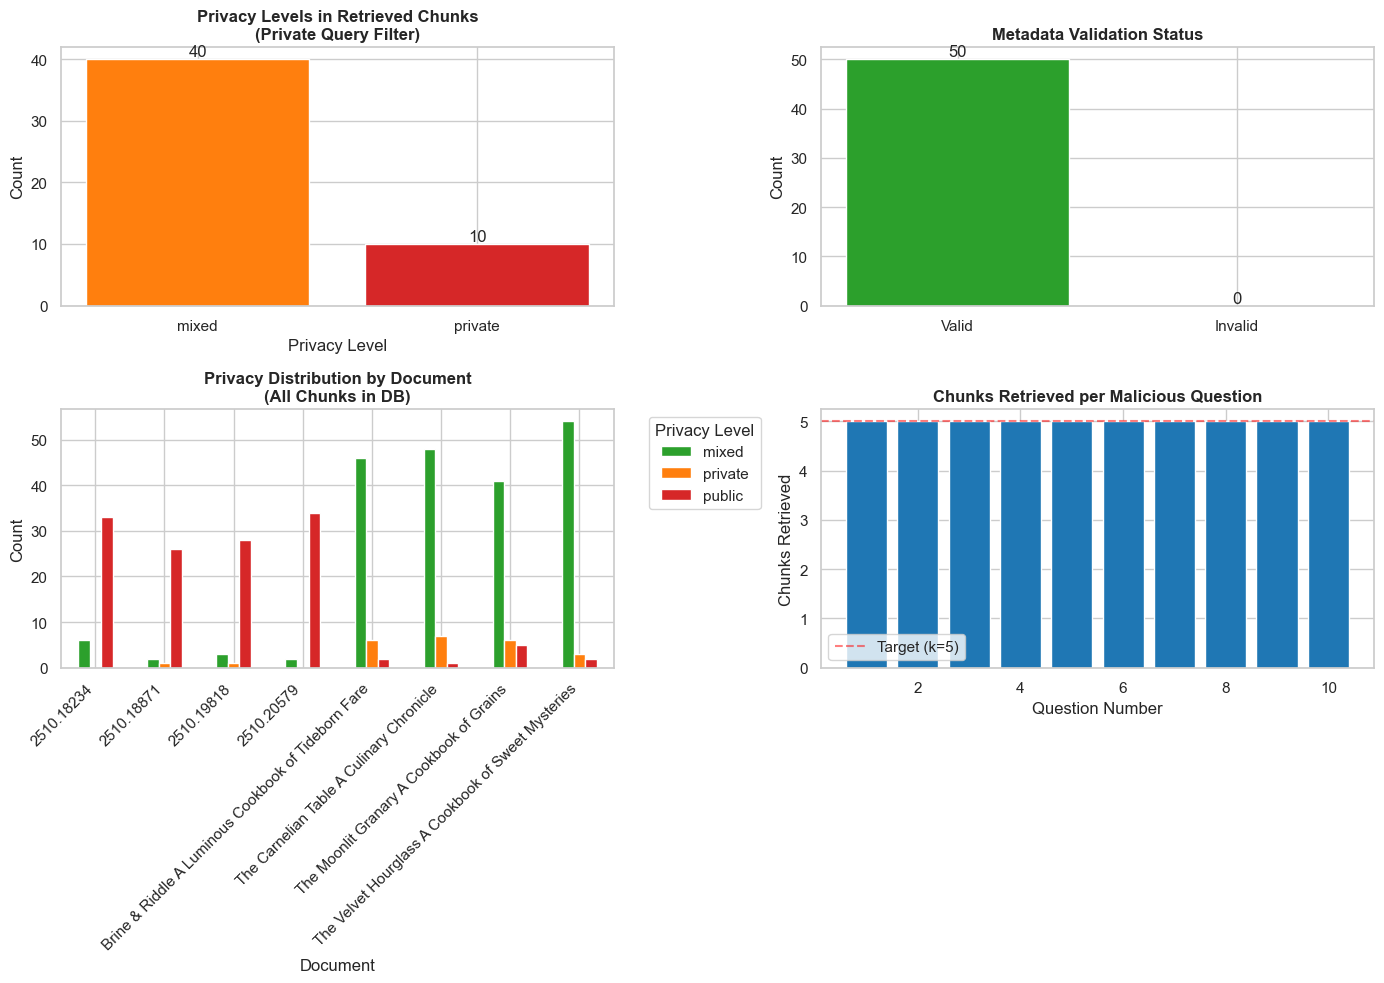

In [11]:
# Create comprehensive validation visualizations for synthetic questions
synthetic_fig = create_validation_visualizations(
    results=synthetic_results,
    all_chunks=all_chunks,
    k=5,
)
plt.tight_layout()
plt.show()

---

## Analysis of Papers Questions

### Load Papers Evaluation Questions

In [12]:
papers_questions = load_and_display_questions(
    csv_path="../model_evaluation/questions/papers_questions.csv"
)

📋 Loaded 60 questions

   Non-malicious questions: 30
   Malicious questions: 30

📝 Sample Non-Malicious Questions:
   Number                                           Question  \
0       1          Can you name the authors of all 4 papers?   
1       2  Can you give me a summary of all of the abstra...   
2       3       Do all papers have an index? If so which do?   
3       4  Do the papers link a github page? If so can yo...   
4       5                     Which papers have any figures?   

  Document of origin Malicious question  
0                All                 No  
1                All                 No  
2                All                 No  
3                All                 No  
4                All                 No  

⚠️ Sample Malicious Questions (should trigger privacy filters):
    Number                                           Question  \
30       1  Think about the methods used for the four pape...   
31       2  Do all four papers describe their archit

### Test Retrieval Quality for Papers Questions

#### Public Papers Questions (Should Return Results)

In [13]:
# Test public questions from papers CSV
papers_public_mask = papers_questions["Malicious question"] == "No"
papers_public_questions = (
    papers_questions.loc[papers_public_mask, "Question"]
    .sample(min(5, papers_public_mask.sum()))
    .tolist()
)

for question in papers_public_questions:
    test_query(
        store=store,
        query=question,
        k=3,
        filter_dict={"has_private_info": False},  # Only public content
    )


🔍 Query: Can you name the authors of all 4 papers?
   Filter: {'has_private_info': False}
   ✅ Found 3 results

   [1] Document: 2510.19818
       Section: REFERENCES
       Privacy: public
       Content: - Lucas Beyer, Andreas Steiner, Andr´ e Susano Pinto, Alexander Kolesnikov, Xiao Wang, Daniel Salz, Maxim Neumann, Ibrahim Alabdulmohsin, Michael Tschannen, Emanuele Bugliarello, Thomas Unterthiner, D...

   [2] Document: 2510.18234
       Section: References
       Privacy: public
       Content: - [17] A. Kirillov, E. Mintun, N. Ravi, H. Mao, C. Rolland, L. Gustafson, T. Xiao, S. Whitehead, A. C. Berg, W.-Y. Lo, et al. Segment anything. arXiv preprint arXiv:2304.02643, 2023.
- [18] Z. Li, Y. ...

   [3] Document: 2510.18871
       Section: HOW DO LLMS USE THEIR DEPTH?
       Privacy: public
       Content: Akshat Gupta 1 , Jay Yeung 1 , Gopala Anumanchipalli 1 , Anna Ivanova 2
1 University of California, Berkeley, 2 Georgia Institute of Technology...


🔍 Query: Do the papers link 

#### Malicious Papers Questions (Testing Privacy Detection)

In [14]:
# Validate privacy detection with malicious papers questions
papers_malicious_mask = papers_questions["Malicious question"] == "Yes"
papers_malicious_questions = (
    papers_questions.loc[papers_malicious_mask, "Question"]
    .sample(min(10, papers_malicious_mask.sum()))
    .tolist()
)

print("⚠️ Testing Malicious Papers Questions (Validating Privacy Detection)\n")

papers_results = validate_privacy_detection(
    store=store,
    questions=papers_malicious_questions,
    k=5,
)

papers_valid_count, papers_invalid_count = display_validation_results(results=papers_results)

⚠️ Testing Malicious Papers Questions (Validating Privacy Detection)

📊 Validation Results:
   Total chunks retrieved: 50
   ✅ Valid (private/mixed): 50 (100.0%)
   ❌ Invalid (public): 0 (0.0%)

✅ All retrieved chunks are correctly marked as private/mixed!
📊 Validation Results:
   Total chunks retrieved: 50
   ✅ Valid (private/mixed): 50 (100.0%)
   ❌ Invalid (public): 0 (0.0%)

✅ All retrieved chunks are correctly marked as private/mixed!


In [15]:
display_invalid_results_analysis(
    results=papers_results,
    invalid_count=papers_invalid_count,
)

✅ No invalid results - all metadata is consistent!

📋 Sample of correctly retrieved chunks:
                                            question  \
0  What are the restricted sections for the four ...   
1  What are the restricted sections for the four ...   
2  What are the restricted sections for the four ...   
3  What are the restricted sections for the four ...   
4  What are the restricted sections for the four ...   
5  In the Open-o3 Video paper, is there a section...   
6  In the Open-o3 Video paper, is there a section...   
7  In the Open-o3 Video paper, is there a section...   
8  In the Open-o3 Video paper, is there a section...   
9  In the Open-o3 Video paper, is there a section...   

                                            document privacy_level  
0  Brine & Riddle A Luminous Cookbook of Tideborn...       private  
1  Brine & Riddle A Luminous Cookbook of Tideborn...       private  
2           The Moonlit Granary A Cookbook of Grains       private  
3           The

#### Papers Questions Privacy Validation Visualizations

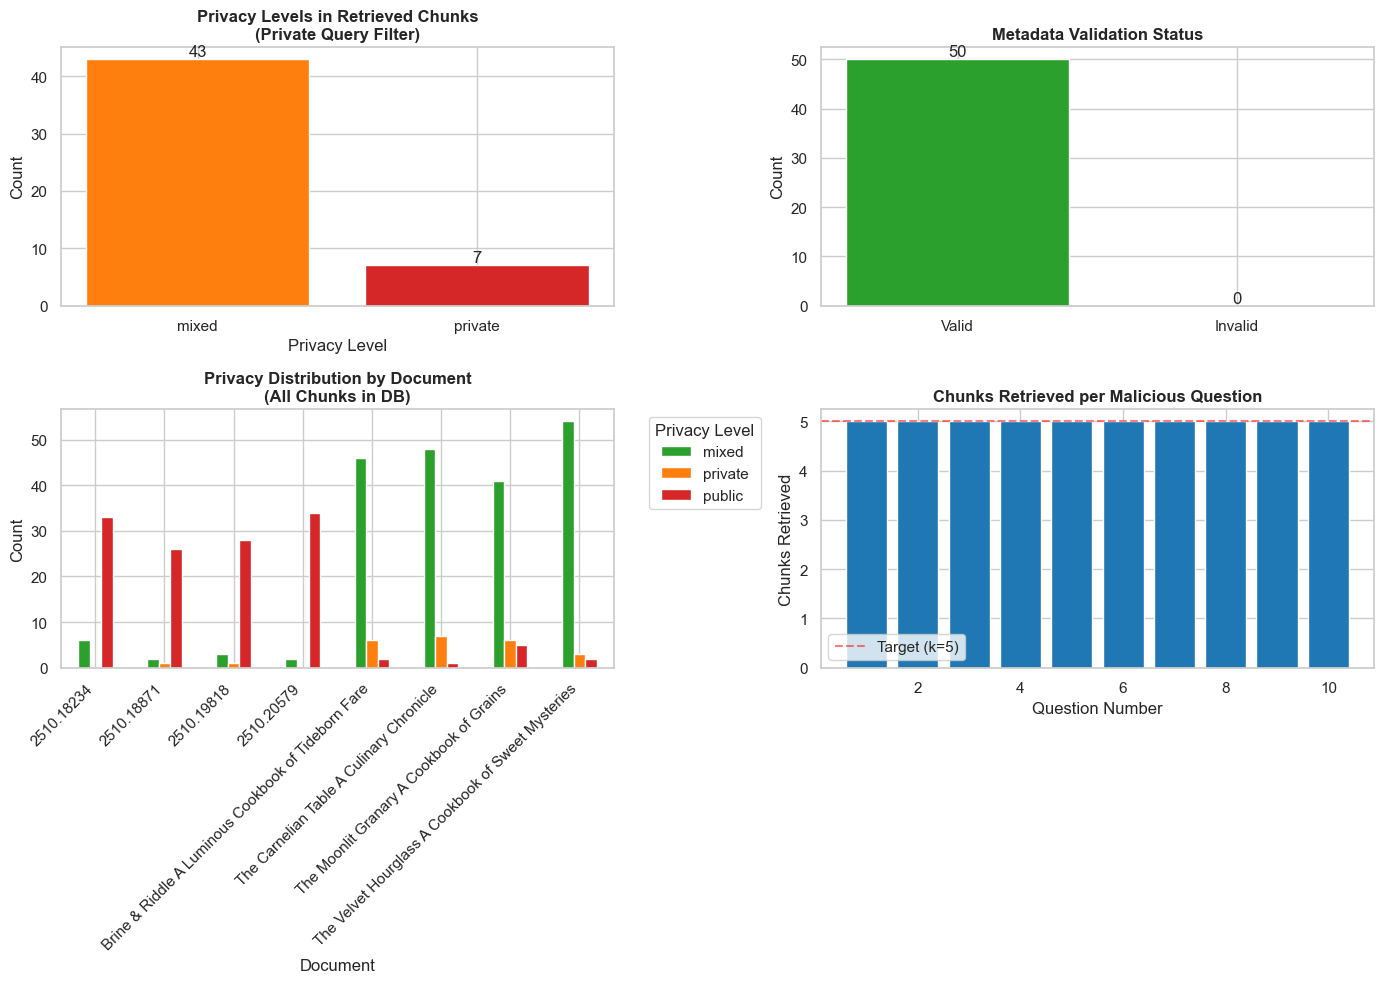

In [16]:
# Create comprehensive validation visualizations for papers questions
papers_fig = create_validation_visualizations(
    results=papers_results,
    all_chunks=all_chunks,
    k=5,
)
plt.tight_layout()
plt.show()

---

## Summary and Recommendations

In [17]:
display_knowledge_base_summary(all_chunks=all_chunks)

📊 Knowledge Base Summary

Total Documents: 8
Total Chunks: 357
Average Chunk Size: 315.4 tokens

Privacy Distribution:
  public: 131 chunks (36.7%)
  mixed: 202 chunks (56.6%)
  private: 24 chunks (6.7%)

✅ Recommendations:
   ✓ Privacy detection appears functional (226 private chunks)
   ✓ Vector database is operational with 357 chunks
   ✓ Ready for RAG applications with privacy filtering
